In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import warnings
import seaborn as sns

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [2]:
# 데이터 불러오기
seoul_people = pd.read_csv('./df_seoul_people.csv', sep=',', encoding='UTF-8')
seoul_bus_station = pd.read_csv('./df_seoul_bus_station.csv', sep=',', encoding='UTF-8')
seoul_moving = pd.read_csv('./df_seoul_moving.csv', sep=',', encoding='UTF-8')
seoul_business = pd.read_csv('./df_seoul_business.csv', sep=',', encoding='UTF-8')

In [3]:
data = pd.merge(seoul_people, seoul_bus_station, how="inner", on="자치구" )
data = pd.merge(data, seoul_moving, how="inner", on="자치구" )
data = pd.merge(data, seoul_business, how="inner", on="자치구" )

In [4]:
data

,자치구,남자,여자,합계,정류장수,노선수,승차총승객수,하차총승객수,승차평균승객수,하차평균승객수,평균 이동 시간(분),이동인구(합),총 이동 시간,총 이동인구,일반 교과 학원,한식 육류요리 전문점,기타주점업
0,종로구,71654,78390,150044,359,107,6030756,5793573,136.745635,131.367580,58.194685,41.924669,28757369,20717410.80,382,1982,1413
1,중구,63365,68392,131757,172,102,4384564,4238810,132.192595,127.798179,56.495425,43.895374,28421662,22082840.96,175,2121,982
2,용산구,105480,113343,218823,325,70,4764100,4663071,136.082150,133.196350,57.799267,35.598387,26930239,16586249.44,573,1184,1332
3,성동구,136779,146555,283334,432,58,3185165,3134742,100.742164,99.147357,57.487400,40.110184,27346124,19079973.16,1494,1545,621
4,광진구,166541,183141,349682,278,43,3207725,3228754,118.756247,119.534782,60.205262,44.344913,26680865,19652113.55,1646,1678,1577
5,동대문구,173830,185713,359543,309,75,5887202,5770880,135.506192,132.828799,59.206579,39.150358,28168063,18626135.28,984,1509,1082
6,중랑구,188685,197925,386610,384,50,4220995,4167084,83.242846,82.179660,62.806200,39.611742,25012883,15775574.40,1045,1504,1000
7,성북구,207616,228447,436063,596,100,6610774,6642472,116.676503,117.235955,59.975355,43.425861,28227521,20438468.24,1755,1334,1030
8,강북구,139260,150567,289827,410,71,5244436,5077041,138.244306,133.831743,65.258796,38.290780,24201877,14200518.80,740,1176,1275
9,도봉구,148622,159162,307784,366,57,3575712,3493061,110.579911,108.023905,66.683308,36.915026,22711868,12572999.34,1162,943,477


In [5]:
data.to_csv('./data.csv', index=False)

# 🌟인사이트🌟
- 자치구별 이동인구와 한식집, 학원, 주점 개수는 양천구의 학원 개수를 제외하고는 유사한 곡선을 그리고 있음
    - 이동인구가 많은 지역에 한식집, 학원, 주점 개수가 많음
    - 양천구를 제외하고는 이동인구만으로도 대중교통 수요 분석이 가능함

- 양천구의 경우 이동인구는 다른 높은 자치구에 비해 낮은편이지만
    - 학원가가 몰려 있어 버스 노선이 부족해 이동하지 못할 수 있어, 양천구에도 노선을 추가한다면 도움이 될 것이다.

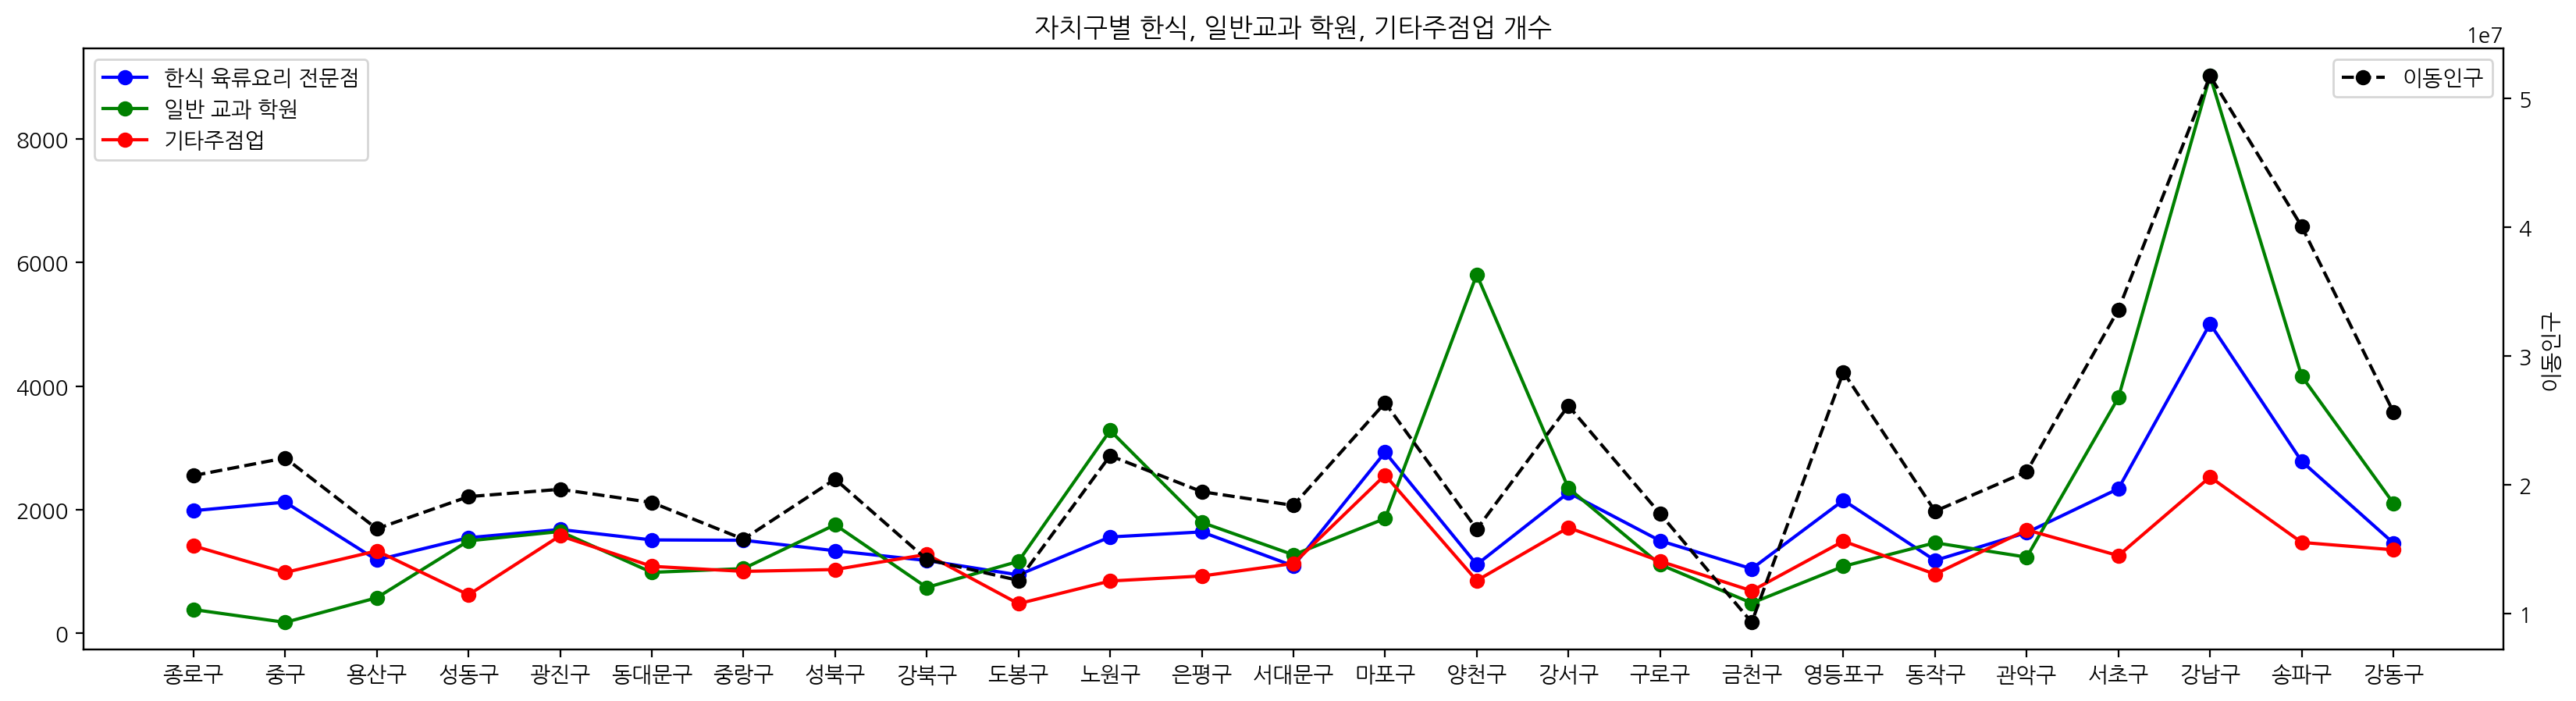

In [23]:
# 주석
plt.figure(figsize=(20,5))
plt.plot(data['자치구'], data['한식 육류요리 전문점'],
        color='blue', linestyle="-", marker='o', label='한식 육류요리 전문점')
plt.plot(data['자치구'], data['일반 교과 학원'],
        color='green', linestyle="-", marker='o', label='일반 교과 학원')
plt.plot(data['자치구'], data['기타주점업'],
        color='red', linestyle="-", marker='o', label='기타주점업')
plt.legend()

# 두 번째 Y축을 추가하여 노선수 그리기
ax2 = plt.gca().twinx()  # 현재 Axes의 twinx() 메서드를 사용하여 Y축 추가
ax2.plot(data['자치구'], data['총 이동인구'], color='black', linestyle="--", marker='o', label='이동인구')
ax2.set_ylabel('총 이동인구', color='black')

plt.title('자치구별 한식, 일반교과 학원, 기타주점업 개수')
plt.xlabel('자치구')
plt.legend()
# plt.ylabel('총 이동 시간')
plt.show()

- 이동인구와 정류장 수를 정규화된 값으로 비교했을 때
    - 중구, 강남구의 경우 이동인구가 정류장 수에 비에 많은 것으로 나타남
    - 의외로 가장 인구가 적은 곳의 수요가 부족했으며, 당연히 높은 면적과 인구가 많은 곳은 대중교통의 수요가 더 높음

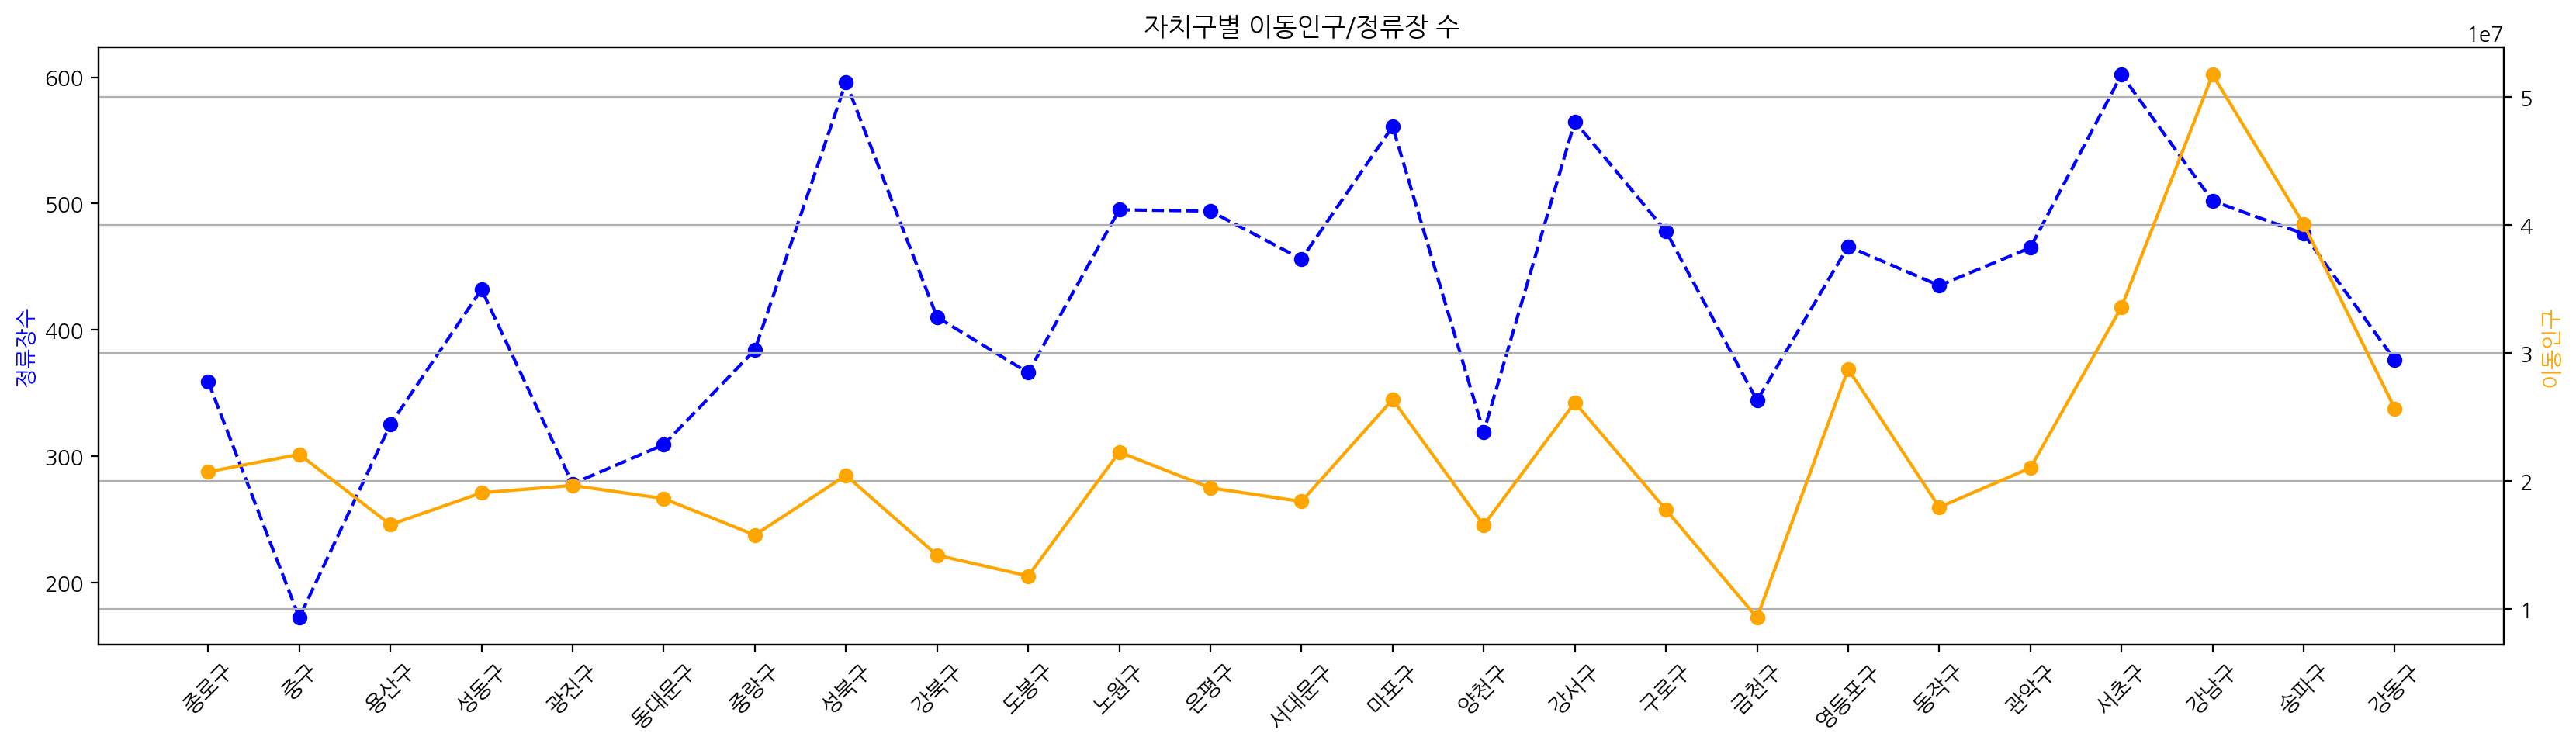

In [31]:
plt.figure(figsize=(20, 5))

# 첫 번째 Y축을 사용하여 정류장수 그리기
plt.plot(data['자치구'], data['정류장수'], color='blue', linestyle="--", marker='o', label='정류장수')
plt.ylabel('정류장수', color='blue')
plt.xticks(rotation=45)  # x축 라벨 회전


# 두 번째 Y축을 추가하여 노선수 그리기
ax2 = plt.gca().twinx()  # 현재 Axes의 twinx() 메서드를 사용하여 Y축 추가
ax2.plot(data['자치구'], data['총 이동인구'], color='orange', linestyle="-", marker='o', label='이동인구')
ax2.set_ylabel('이동인구', color='orange')

# 레이블과 제목 설정
plt.title('자치구별 이동인구/정류장 수')
plt.xlabel('자치구')
plt.grid()

plt.show()

- 특이한 점은 강동구의 경우 평균 이동 시간이 매우 높음에도 노선수가 현저히 부족하다는 것이다.
    - 강동구의 경우 인구수가 전체 평균보다 높으며, 25 자치구 중 인구수가 7위
    - 이런 평균 이동 시간과 노선수 상관을 통해 강동구에도 버스 노선 추가가 필요할 것이다.

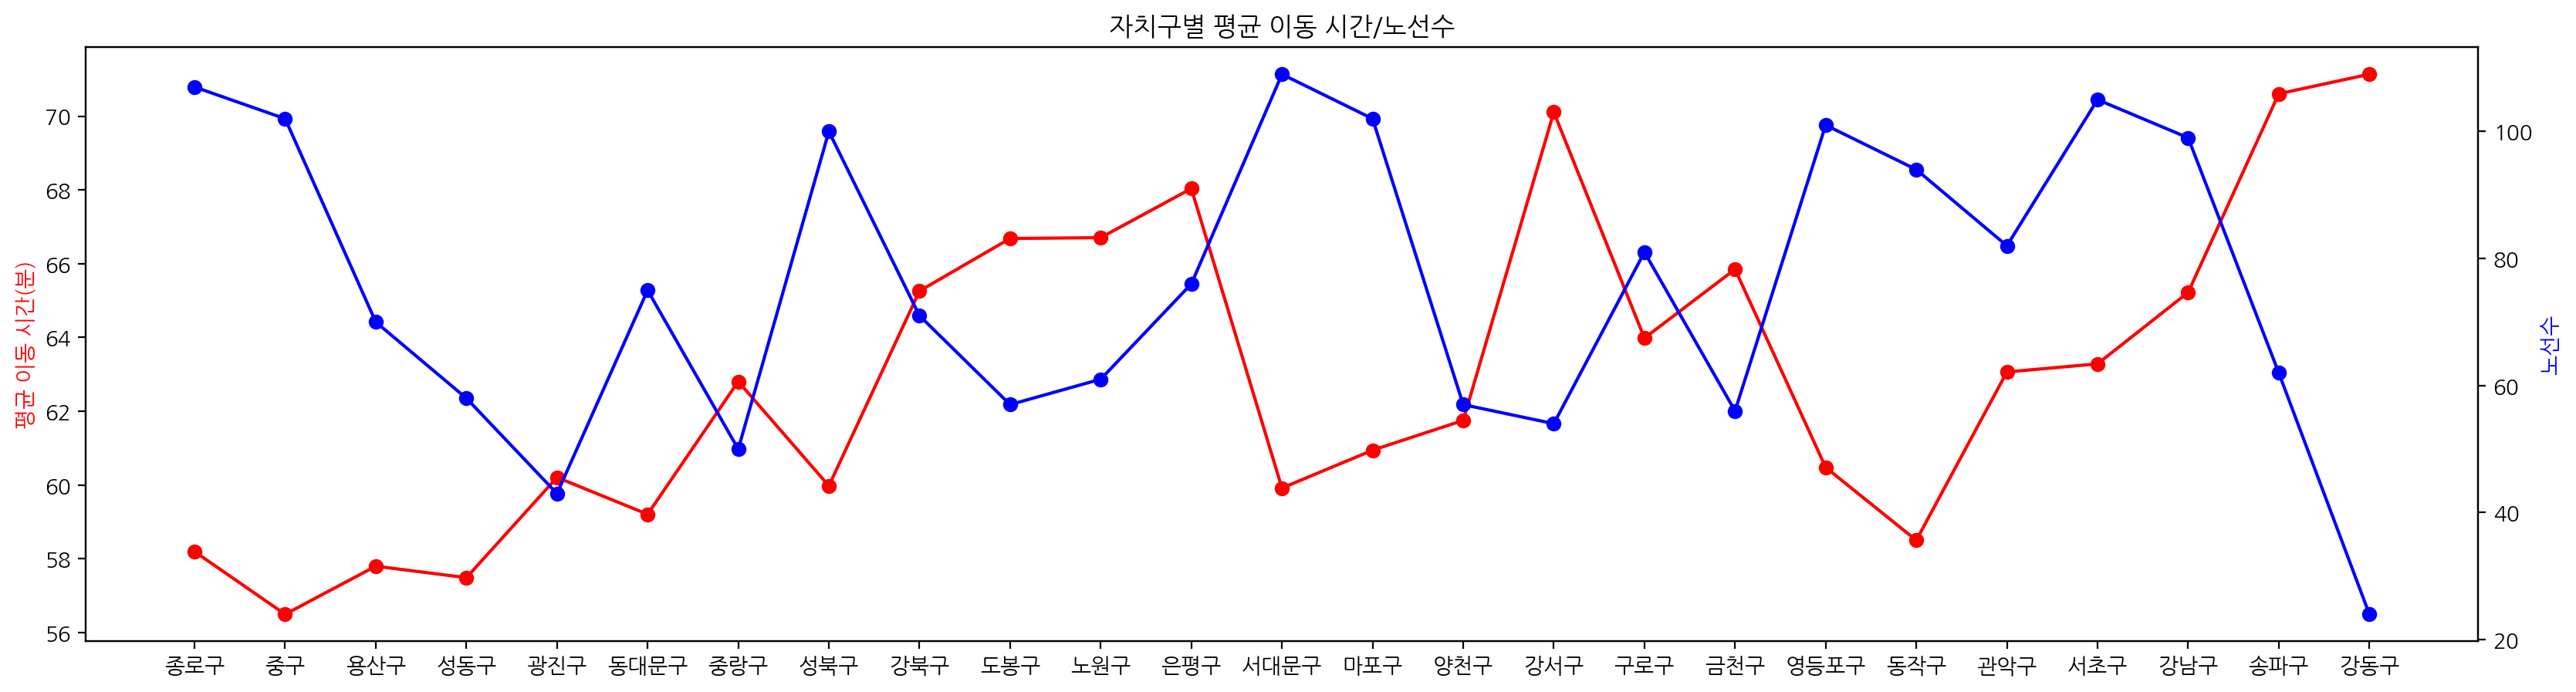

In [29]:
# 주석
plt.figure(figsize=(20,5))
plt.plot(data['자치구'], data['평균 이동 시간(분)'],
        color='red', linestyle="-", marker='o', label='평균 이동 시간')
plt.ylabel('평균 이동 시간(분)', color='red')  # Y축 레이블 추가

ax2 = plt.gca().twinx()  # 현재 Axes의 twinx() 메서드를 사용하여 Y축 추가
ax2.plot(data['자치구'], data['노선수'],
        color='blue', linestyle="-",marker='o',label='노선수')
ax2.set_ylabel('노선수', color='blue')  # Y축 레이블 추가


plt.title('자치구별 평균 이동 시간/노선수')
plt.show()

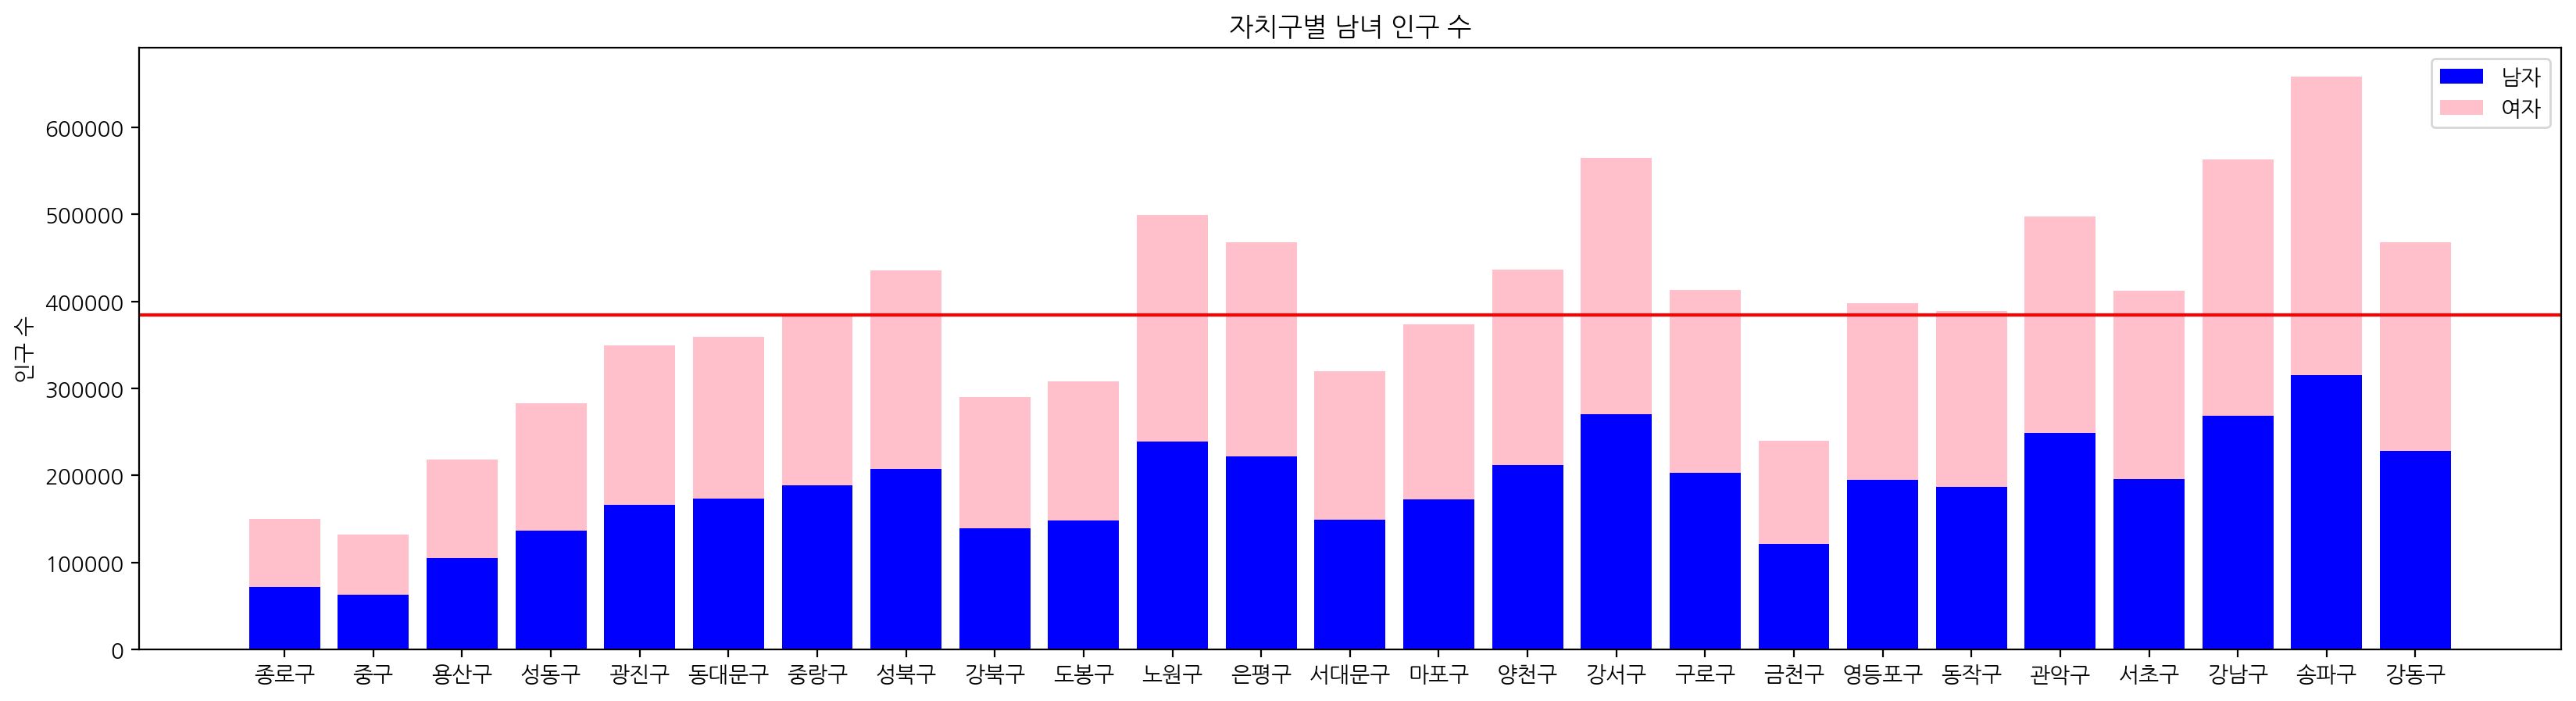

In [27]:
# 여자, 남자, 합계의 값이 int가 아닌 str형으로 plot 생성에 오류 발생
plt.figure(figsize=(20,5))
plt.bar(data['자치구'], data['남자'], color='blue', label='남자')
plt.bar(data['자치구'], data['여자'], color='pink', label='여자', bottom=seoul_people['남자'])

# 평균값 선 추가-
plt.axhline(seoul_people['합계'].mean(),color = 'r')

# 레이블 설정
plt.ylabel('인구 수')
plt.title('자치구별 남녀 인구 수')
plt.legend()